In [2]:
import pandas as pd
import re

In [3]:
def categorize(text):
    if not isinstance(text, str) or text.strip() == '' or text.strip() == 'nan':
        return 'Other'
    t = text.lower()

        # Israel-Palestine
    if any(w in t for w in ['israel', 'israeli', 'palestine', 'palestinian', 'gaza', 'rafah',
                             'west bank', 'hamas', 'idf', 'netanyahu', 'unrwa', 'jabalia',
                             'ramallah', 'hezbollah', 'al-aqsa', 'ceasefire', 'tel aviv',
                             'occupied', 'zionist', 'intifada', 'settlers', 'bds bill',
                             'october 7', 'oct 7']):
        return 'Israel-Palestine Conflict'

    # Russia-Ukraine
    if any(w in t for w in ['ukraine', 'ukrainian', 'russia', 'russian', 'putin', 'zelensky',
                             'kyiv', 'moscow', 'kremlin', 'navalny', 'donbas', 'nord stream',
                             'zaluzhnyi', '750th day', '749th day', '748th day', '747th day',
                             'war enters its', 'kharkiv', 'wagner','leonid volkov']):
        return 'Russia-Ukraine War'
    
    # US Politics
    if any(w in t for w in ['trump', 'biden', 'us election', 'congress', 'democrat', 'republican',
                             'white house', 'senate', 'supreme court', 'blinken', 'teixeira',
                             'super tuesday', 'nikki haley', 'us states', 'presidential prim',
                             'us secretary of state', 'state department spokesman', 'matthew miller',
                             'bushnell', 'aaron bushnell', 'us officials urge','kamala harris','mar-a-lago',
                            'raffensperger', 'designated survivor','katie britt', 'us president', 'roe v wade',
                            'american election','pentagon report', 'ufo ','hunter biden', 'state of the union',
                            'bolsonaro', 'teixeira', 'desantis',
                            'mike johnson']):
        return 'US Politics & Elections'    
   
    # Arts, Culture & Society
    if any(w in t for w in ['oscar', 'emmy', 'grammy', 'bafta', 'film', 'movie', 'music',
                             'poetry', 'poet', 'darwish', 'simsimiyya', 'folk music',
                             'art ', 'artist', 'cultural', 'literature', 'oppenheimer',
                             'hollywood', 'cinema', 'novel', 'hip-hop', 'album cover',
                             'album ', 'sxsw', 'south by southwest', 'nyepi', 'bali', 'ramadan',
                             'fasting hours', 'iftar', 'holy month', 'new year', 'balinese',
                             'crayons', 'school', 'tae kwon', 'taekwon', 'indigenous women',
                             'barbie', 'taylor swift', 'beyonce', 'oscars','ryan gosling',
                             'museum', 'exhibition', 'fashion ','red carpet', 'celebrity', 'pop star',
                             'singer','royal family', 'queen camilla', 'princess of wales','king charles',
                             'kate middleton', 'meghan', 'prince harry','kensington palace', 'buckingham',
                             'coronation','paul o\'grady', 'kate garraway', 'derek draper','chocolate ', 'john cena',
                             'emma stone','tv show', 'sitcom', 'drama series', 'documentary','reality tv', 'soap opera',
                             'theatre', 'theater','concert ', 'music video', 'aya nakamura', 'french singer','guide dog',
                             'dogs', 'dog show', 'crufts','veteran actor', 'actress', 'actor ', 'director ','just ken',
                             'costume design', 'ashley jensen', 'shetland','lady gabriella', 'giant redwood','bbc travel',
                             'bbc future', 'dua lipa', 'coldplay', 'glastonbury', 'wordle', 'new york times game',
                            'josh cavallo', 'pamela holt', 'travel to 80 countries', 'coolest streets',
                             'pi day', 'pie day', 'john galliano', 'cancel culture', 'yeezy', 'adidas yeezy',
                             'solar eclipse', 'eclipse', 'fragrance', 'perfume', 'azzi glasser', 'stamp collect',
                             'philatel', 'rapturous', 'pop culture', 'viral', 'rapid vienna', 'coming out gay',
                             'first gay soccer']):
        return 'Arts, Culture & Society'
    
    # Sports
    if any(w in t for w in ['cricket', 'psl', 'multan sultans', 'peshawar zalmi', 'rohit sharma',
                             'ashwin', 'real madrid', 'ancelotti', 'football match', 'soccer match',
                             'olympics', 'world cup final', 'nba', 'tennis match', 'rugby',
                             'fifa', 'tournament final', 'championship win', 'formula 1', 'f1 race',
                             'athlete', 'sporting', 'premier league', 'champions league', 'la liga',
                            'laliga','nba ', 'nfl ', 'nhl ', 'mlb ', 'tennis ', 'wimbledon','rugby ',
                            'six nations', 'super bowl', 'f1 ','fifa ', 'world cup', 'golf ','arsenal ',
                            'manchester ', 'chelsea ', 'liverpool ','barcelona ', 'atletico', 'juventus',
                            'green bay packers', 'bakhtiari', 'ramsdale', 'athlete','cameroon football',
                            'football club', 'luton town', 'bernhard langer', 'the masters', 'pga ', 'lpga',
                            'ski tour', 'skiing', 'snowboard', 'freedom shield', 'connor o\'leary', 'surfer',
                            'surfing','david bakhtiari', 'nfl player']):
        return 'Sports'
    
    # Climate & Environment
    if any(w in t for w in ['climate change', 'climate crisis', 'global warming','emission', 'greenhouse gas',
                            'carbon', 'net zero','renewable energy', 'fossil fuel', 'electric vehicle','solar panel',
                            'deforestation', 'biodiversity','pollution', 'wildfire', 'drought', 'coral reef','warming seas',
                            'marine species', 'cyclone', 'hurricane','flooding', 'flash flood', 'heatwave', 'heat wave',
                            'natural disaster', 'earthquake', 'tsunami', 'landslide','heavy rain', 'torrential rain',
                            'six months worth of rain','winter storm', 'bird flu', 'avian flu','conservation concern',
                            'fossil forest', 'redwood tree', 'powerful storm', 'weather hazard', 'storm system',
                             'california storm', 'california rain', 'giant sequoia', 'sequoia', 'growing at a rate',
                             'water index', 'water scarcity', 'climate', 'greenhouse', 'renewable', 'fossil fuel',
                             'electric vehicle', 'solar', 'global warming', 'environmental', 'smokehouse creek',
                             'coral reef', 'warming seas', 'marine species', 'heavy rain', 'cyclone', 'flood',
                             'natural disaster', 'earthquake']):
        return 'Climate & Environment'
    
    # Health & Science
    if any(w in t for w in ['covid', 'pandemic', 'vaccine', 'vaccination','measles', 'disease', 'virus ', 'bacterial',
                            'iron lung', 'paul alexander', 'malnutrition','hospital ', 'medical ', 'cancer ', 'surgery ',
                            'mental health', 'long covid', 'nhs ','postpartum', 'depression treatment', 'wim hof',
                            'menopause', 'menopausal', 'basal cell', 'skin cancer','space medicine', 'microgravity',
                            'nasa ', 'lunar','spacex', 'starship', 'rocket launch','study found', 'scientists say',
                            'researchers find','gene ', 'dna ', 'pharmaceutical', 'drug trial','astrazeneca', 'zuranolone',
                            'fda ','clinic ', 'health concern', 'smoke inhalation', 'tapeworm', 'parasite', 'larvae in',
                            'worms in brain', 'psittacosis', 'parrot fever', 'car-t therapy', 'cart therapy', 'car t ',
                             'migraine ', 'brain tumour', 'brain tumor', 'dogs and mental health', 'decompressing',
                             'walking and health', 'exercise and', 'waking up at night', 'sleep ', 'biocon',
                             'biopharmaceutical', 'amolyt', 'trainee doctors', 'doctors walkout', 'doctors strike',
                             'menopausal whale', 'whale menopause', 'hospital fire', 'outbreak', 'health agency',
                             'maori health', 'public health', 'nasa', 'lunar base', 'space']):
        return 'Health & Science'
    
    # Technology
    if any(w in t for w in ['artificial intelligence', ' ai ', 'machine learning','tiktok', 'tech company', 'digital ',
                            'cybersecurity', 'cyber attack', 'hacking', 'ransomware','software ', 'algorithm', 'robot ',
                            'automation','social media', 'elon musk', 'facebook', 'meta ','google ', 'apple ', 'microsoft ',
                            'amazon ','privacy ', 'data breach', 'tesla ', 'foxconn','laser weapon', 'drone', 'tech giant',
                            'startup','cryptocurrency', 'bitcoin', 'chatgpt', 'openai','fairer devices', 'curatorial knowledge',
                            'self-driving', 'autonomous vehicle', 'boeing', 'nvidia ', 'jensen huang', 'gpu ',
                            'semiconductor', 'tencent ', 'bytedance', 'video games company', 'cyberattack', 'cyber-attack',
                            'government websites', 'vertical farm', 'gigafarm', 'refarm', 'driver-less', 'driverless',
                            'self driving', 'hometown services', 'hvac', 'heating cooling', 'electric vehicles recall',
                            'hyundai recall', 'volkswagen ev', 'ev launch', 'stamp collecting', 'philately digital',
                            'tech ', 'digital', 'cyber', 'software', 'robot', 'social media', 'elon musk', 'facebook',
                            'meta ', 'google', 'airbnb', 'privacy', 'data ', 'tesla', 'hypersonic', 'battle tank',
                            'technology conference', 'entrepreneurs', 'dynamic pricing', 'boeing', 'whistleblower',
                            'boeing safety', 'drone strike', 'biases', 'ai technologies']):
        return 'Technology'

    # Middle East & North Africa
    if any(w in t for w in ['houthi', 'yemen', 'red sea','iran ', 'iranian', 'saudi ', 'qatar ','iraq ', 'iraqi ',
                            'syria', 'syrian','lebanon ', 'lebanese', 'jordan ', 'egypt ','libya', 'algeria', 'morocco ',
                            'tunisia', 'kuwait','bahrain', 'oman ', 'uae ', 'al-qaeda','khamenei', 'tehran',
                            'yemeni', 'egyptian', 'aqap', 'assembly of experts', 'riad salameh', 'iran election',
                            'hossein dehghan']):
        return 'Middle East & North Africa'
    
    # Africa
    if any(w in t for w in [' africa', 'african ', 'nigeria ', 'nigerian','kenya ', 'kenyan', 'ethiopia ', 'ethiopian',
                            'somalia ', 'somali', 'sudan ', 'senegal ','ghana ', 'south africa', 'congo ', 'mali ',
                            'niger ', 'burkina', 'mozambique', 'tanzania ','rwanda ', 'zimbabwe ', 'chad ', 'cameroon ',
                            'wigwe', 'nigerian stock exchange','joshlin smith', 'coptic', 'kuriga', 'kaduna', 'chad',
                            'deby', 'mnangagwa', 'zimbabwe', 'n\'djamena', 'yaya dillo', 'fatima muniz', 'port-au-prince',
                            'ariel henry']):
        return 'Africa'    
    
    # Latin America
    if any(w in t for w in ['latin america', 'brazil ', 'brazilian', 'mexico ', 'mexican','colombia ', 'venezuela ',
                            'argentina ','chile ', 'peru ', 'caribbean', 'cuba ', 'haiti ','bolivia ', 'panama ',
                            'maduro', 'bolsonaro','lula ', 'cartel', 'chérizier', 'puerto rico','ariel henry',
                            'citgo', 'venezuela-owned oil', 'pdvsa', 'haitian', 'bolivian', 'otarola', 'martinelli',
                            'panama', 'machado', 'machado ban' ]):
        return 'Latin America & Caribbean'

    # Europe
    if any(w in t for w in ['europe', 'european union', ' eu ', 'germany ', 'german ','france ', 'french ', ' uk ',
                            'britain ', 'british ','england ', 'scotland ', 'wales ', 'northern ireland','poland ',
                            'hungary ', 'sweden ', 'swedish','finland ', 'nato ', 'brussels', 'paris ', 'berlin ',
                            'london ', 'spain ', 'spanish ', 'italy ', 'italian ','greece ', 'denmark ', 'norway ',
                            'portugal ','ireland ', 'dutch ', 'netherlands', 'belgium ','rishi sunak', 'sunak', 'tory ',
                            'labour party', 'keir starmer', 'macron ', 'scholz','uk budget', 'uk parliament',
                            'uk government','scottish parliament', 'michael matheson','romanian', 'j.k. rowling',
                            'jk rowling','cambridge university', 'oxford university', 'elihu yale','europe ', 'dubrovnik',
                            'holiday parks','council issued', 'bbc has found', 'foreign newspaper ownership',
                            'foreign states owning newspapers', 'anheuser-busch', 'ab inbev','belgian brewer',
                            'switzerland ', 'swiss ', 'austria ', 'czech ', 'slovak ', 'romanian ', 'balkan',
                            'zagreb', 'private credit', 'european private', 'markus krebber', 'germany power',
                             'european market', 'european markets', 'senior management swiss',
                             'british', 'poland', 'hungary', 'sweden', 'finland', 'nato',
                             'brussels', 'paris', 'berlin', 'london', 'spain', 'italy',
                             'greece', 'serbia', 'denmark', 'norway', 'portugal', 'ireland',
                             'dutch ', 'netherlands', 'ridouan taghi', 'taghi', 'conservative party',
                             'frank hester', 'chancellor scholz', 'uk budget', 'house of lords',
                             'jacqueline foster']):
        return 'Europe'

    # Asia & Pacific
    if any(w in t for w in ['china ', 'chinese ', 'taiwan ', 'north korea', 'south korea','japan ', 'japanese ', 'india ',
                            'indian ', 'pakistan ','bangladesh ', 'myanmar ', 'rohingya', 'afghanistan ','indonesia ',
                            'philippines ', 'laos ', 'asean','australia ', 'australian ', 'new zealand', 'asia ','thai ',
                            'thailand ', 'vietnam ', 'cambodia ','hong kong', 'marcos ', 'imran khan', 'shehbaz',
                            'maryam nawaz', 'peshawar ', 'himalayan','singapore ', 'malaysia ','korea dmz', 'dmz ',
                            'freedom village','hyundai ', 'kia ', 'samsung ', 'foxconn','pacific ', 'jakarta ',
                            'thaksin', 'tencent', 'bytedance', 'modi ', 'narendra', 'electoral trust india',
                            'india business group', 'india market', 'india election', 'india small-cap', 'arun goel',
                            'india poll', 'china', 'chinese', 'taiwan', 'japan', 'india', 'indian', 'pakistan',
                            'bangladesh', 'myanmar', 'rohingya', 'afghanistan', 'indonesia', 'philippines', 'laos',
                            'asean', 'australia', 'asia', 'thai', 'vietnam', 'cambodia', 'east timor', 'leh', 'kargil',
                            'karachi', 'beijing', 'kashmir', 'sri lanka', 'nepal', 'dhaka', 'hong kong', 'marcos',
                            'joko widodo', 'imran khan', 'shehbaz sharif', 'maryam nawaz', 'punjab', 'peshawar',
                            'himalayan', 'wakeel', 'second thomas shoal', 'shervin hajipour', 'shervin']):
        return 'Asia & Pacific'

    # Human Rights & Social Issues
    if any(w in t for w in ['human rights', 'torture', 'discrimination','refugee ', 'migrant ', 'asylum seeker','protest ',
                            'activist ', 'democracy ','lgbtq', 'transgender', 'gender equality','abortion', 'hate speech',
                            'sexual aggression','sex trafficking', 'nobel peace', 'whistleblower','press freedom',
                            'racial ', 'racism ', 'antisemitism','police brutality', 'indigenous ', 'tribal rights',
                            'disability rights', 'autism','homeless', 'poverty ', 'inequality','duchess of sussex',
                            'andrew tate','mass protests', 'politically motivated', 'gender identity', 'trans rights',
                            'citigroup harassment', 'workplace harassment', 'sexual harassment', 'arkansas transgender',
                            'driver licence gender', 'lower-income americans', 'income inequality', 'un women',
                            'gender equality stalled', 'human rights', 'torture', 'discrimination', 'refugee', 'migrant',
                            'asylum', 'protest', 'activist', 'democracy', 'freedom', 'oppression', 'detention', 'prisoner',
                            'lgbtq', 'women rights', 'hate speech', 'sexual aggression', 'andrew tate', 'nobel peace',
                            'women\'s history', 'afghan women', 'muslim activism', 'smugglers', 'deportation', 'deportees',
                            'gig workers', 'stripped their earn', 'drug war killings', 'death penalty', 'political prisoner',
                            'carlos belo', 'directive 24', '88 project', 'mass killing', 'ottawa mass']):
        return 'Human Rights & Social Issues'        

    # Economy & Business
    if any(w in t for w in ['economy ', 'economic ', 'gdp ', 'inflation','stock market', 's&p ','oil price', 'energy price',
                            'currency ','investment ', 'imf ', 'world bank','interest rate', 'federal reserve', 'fed rate',
                            'money laundering', 'tax ', 'budget ', 'deficit ','insurance rate', 'consumer price',
                            'dynamic pricing', 'shrinkflation', 'cost of living','supply chain', 'shipping disruption',
                            'merger ', 'acquisition ', 'earnings report', 'tariff ','supermarket', 'grocery',
                            'financial scam', 'fraud ', 'pension ','wage ', 'salary ', 'pay rise', 'buyout firm',
                            'private equity', 'venture capital', 'nvidia stock', 'market outlook', 'global markets',
                            'breakingviews', 'citigroup invest', 'citigroup invest', 'electoral trust donate',
                            'political donation', 'india business donate', 'business group donated', 'car insurance',
                            'mcdonald\'s cheaper', 'fast food price', 'cookie monster shrink', 'shrinkflation cookie',
                            'adidas yeezy stock', 'adidas revenue', 'american airlines', 'airline pilot', 'economy',
                            'economic', 'trade', 'gdp', 'inflation', ' market ', 'oil demand', 'energy agency', 'currency',
                            'investment', 'financial', 'iea', 'opec', 'shipping', 'trillion', 'billion dollar',
                            'dynamic pricing', 'money laundering', 'riad salameh', 'tax cut', 'sanctions regime', 'budget',
                            'debt', 'imf', 'world bank', 'airline', 'direct flights', 'delta air', 'number of airlines',
                            'political donations', 'fundraising' ]):
        return 'Economy & Business'   
    
    # Humanitarian Aid
    if any(w in t for w in ['humanitarian', 'humanitarian crisis', 'humanitarian aid', 'famine ','starvation ',
                            'displaced people', 'relief effort', 'unicef', 'unhcr', 'food crisis','aid worker',
                            'aid convoy', 'aid drops', 'wfp ', 'famine', 'starvation', 'relief', 'hunger took',
                            'children survive', 'empty plates', 'two mothers recount', 'six hours to queue']):
        return 'Humanitarian Crisis & Aid'    
    
    # Crime & Justice
    if any(w in t for w in ['murder', 'killed ', 'stabbed ', 'shooting ', 'gunman','arrested ', 'convicted ', 'sentenced ',
                            'prison ','court ', 'judge ', 'verdict ', 'guilty ','police ', 'officers ', 'investigation ',
                            'suspect ', 'crime ', 'theft ', 'burglary ','hijack', 'catamaran', 'post-mortem',
                            'cause of death','mass killing', 'hostage', 'kidnap','school shooting', 'fatal shooting',
                            'fatally shot','drug charges', 'weapons charges', 'extradited','explosion ', 'detonated',
                            'bomb ', 'blast ', 'john barnett', 'boeing whistleblower death', 'mob boss', 'ridouan taghi',
                            'drug kingpin', 'gangster', 'carjacking', 'road rage', 'arson ', 'fire at ', 'fire in ',
                             'building fire', 'warehouse fire']):
        return 'Crime & Justice'

    return 'Other'

# Final run + save
for fname in ['al_jazeera', 'bbc', 'cnn', 'reuters']:
    df = pd.read_csv(f'C:/Users/aksha/Documents/Github Datasets/Social Media Engagement/{fname}.csv')
    df['Category'] = df['text'].apply(categorize)
    df['Source'] = fname.upper()
    
    counts = df['Category'].value_counts()
    other_pct = round((df['Category'] == 'Other').sum() / len(df) * 100, 1)
    print(f'{fname.upper()} — {len(df)} rows — {other_pct}% Other remaining')
    print(counts.to_string())
    print()
    
    df.to_csv(f'C:/Users/aksha/Documents/Github Datasets/Social Media Engagement/{fname}_updated.csv', index=False)

print('All saved.')

AL_JAZEERA — 1000 rows — 5.4% Other remaining
Category
Israel-Palestine Conflict       521
Russia-Ukraine War               70
Asia & Pacific                   66
Other                            54
US Politics & Elections          52
Arts, Culture & Society          43
Europe                           32
Africa                           30
Middle East & North Africa       29
Human Rights & Social Issues     22
Technology                       21
Climate & Environment            14
Latin America & Caribbean        11
Sports                            9
Health & Science                  9
Crime & Justice                   9
Economy & Business                6
Humanitarian Crisis & Aid         2

BBC — 1000 rows — 54.2% Other remaining
Category
Other                           542
Arts, Culture & Society         145
Europe                           67
Crime & Justice                  43
Russia-Ukraine War               30
Health & Science                 30
US Politics & Elections        

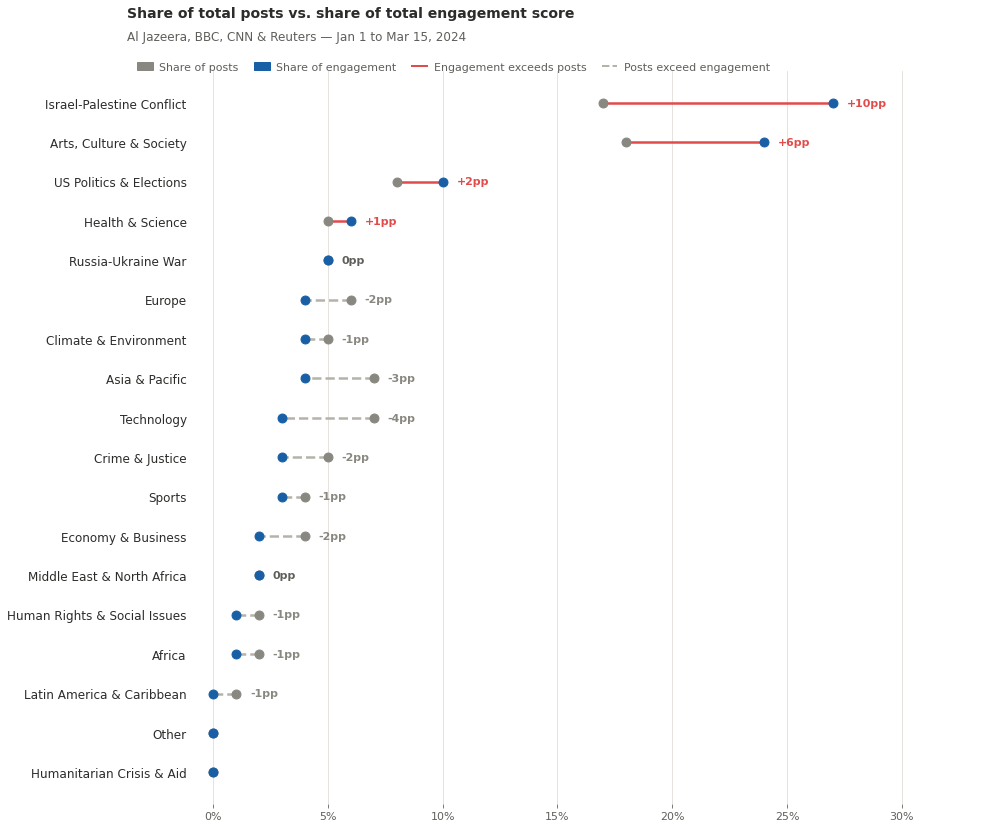

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

data = [
    {'topic': 'Israel-Palestine Conflict',    'posts': 17, 'engagement': 27},
    {'topic': 'Arts, Culture & Society',      'posts': 18, 'engagement': 24},
    {'topic': 'US Politics & Elections',      'posts': 8,  'engagement': 10},
    {'topic': 'Health & Science',             'posts': 5,  'engagement': 6 },
    {'topic': 'Russia-Ukraine War',           'posts': 5,  'engagement': 5 },
    {'topic': 'Europe',                       'posts': 6,  'engagement': 4 },
    {'topic': 'Climate & Environment',        'posts': 5,  'engagement': 4 },
    {'topic': 'Asia & Pacific',               'posts': 7,  'engagement': 4 },
    {'topic': 'Technology',                   'posts': 7,  'engagement': 3 },
    {'topic': 'Crime & Justice',              'posts': 5,  'engagement': 3 },
    {'topic': 'Sports',                       'posts': 4,  'engagement': 3 },
    {'topic': 'Economy & Business',           'posts': 4,  'engagement': 2 },
    {'topic': 'Middle East & North Africa',   'posts': 2,  'engagement': 2 },
    {'topic': 'Human Rights & Social Issues', 'posts': 2,  'engagement': 1 },
    {'topic': 'Africa',                       'posts': 2,  'engagement': 1 },
    {'topic': 'Latin America & Caribbean',    'posts': 1,  'engagement': 0 },
    {'topic': 'Other',                        'posts': 0,  'engagement': 0 },
    {'topic': 'Humanitarian Crisis & Aid',    'posts': 0,  'engagement': 0 },
]

topics     = [d['topic']      for d in data]
posts      = [d['posts']      for d in data]
engagement = [d['engagement'] for d in data]

# Use a clean, highly legible font
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['text.antialiased'] = True

# Larger figure size gives more room for text to breathe
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Vertical gridlines
for x in range(0, 35, 5):
    ax.axvline(x, color='#e0ddd8', linewidth=0.8, zorder=1)

# Connecting lines and dots
for i, (p, e) in enumerate(zip(posts, engagement)):
    if p != e:
        color     = '#E24B4A' if e > p else '#B4B2A9'
        linestyle = '-' if e > p else '--'
        ax.plot([p, e], [i, i], color=color, linewidth=2.5,
                linestyle=linestyle, zorder=2)

    ax.scatter(p, i, color='#888780', s=80, zorder=3)
    ax.scatter(e, i, color='#185FA5', s=80, zorder=3)

    # Gap label
    gap = e - p
    if p > 0 or e > 0:
        label     = f'+{gap}pp' if gap > 0 else f'{gap}pp' if gap < 0 else '0pp'
        color_lbl = '#E24B4A' if gap > 0 else '#888780' if gap < 0 else '#5F5E5A'
        x_label   = max(p, e) + 0.6
        ax.text(x_label, i, label, va='center', ha='left',
                fontsize=11, color=color_lbl, fontweight='bold')

# Axes
ax.set_yticks(range(len(topics)))
ax.set_yticklabels(topics, fontsize=12, color='#2C2C2A')
ax.set_xlim(-1, 34)
ax.set_ylim(-0.8, len(topics) - 0.2)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.tick_params(axis='x', colors='#5F5E5A', labelsize=11)
ax.tick_params(axis='y', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.88)

# Title
fig.text(
    0.13, 0.955,
    'Share of total posts vs. share of total engagement score',
    fontsize=14, fontweight='bold', color='#2C2C2A',
    ha='left', va='top', transform=fig.transFigure
)
fig.text(
    0.13, 0.928,
    'Al Jazeera, BBC, CNN & Reuters — Jan 1 to Mar 15, 2024',
    fontsize=12, color='#5F5E5A',
    ha='left', va='top', transform=fig.transFigure
)

# Legend
legend_elements = [
    mpatches.Patch(color='#888780', label='Share of posts'),
    mpatches.Patch(color='#185FA5', label='Share of engagement'),
    mlines.Line2D([], [], color='#E24B4A', linewidth=2, label='Engagement exceeds posts'),
    mlines.Line2D([], [], color='#B4B2A9', linewidth=2,
                  linestyle='--', label='Posts exceed engagement'),
]
fig.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(0.13, 0.902),
    ncol=4,
    fontsize=11,
    frameon=False,
    labelcolor='#5F5E5A',
    handlelength=1.4,
    handletextpad=0.6,
    columnspacing=1.4,
)

# Save at 300 dpi — print-quality resolution
plt.savefig('dotplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()